<a href="https://colab.research.google.com/github/risha2211/Quantum-Computing/blob/main/optimization/quantum-approximate-optimization-algorithm/max-cut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Max-Cut

##Problem Statement

The Max-Cut problem is a graph optimization problem.

Given a graph consisting of vertices and edges, the goal is to divide the vertices into two sets such that the maximum possible number of edges have their endpoints in different sets.

For example, if two connected vertices are placed in different sets, the edge between them is cut and contributes to the cut value.

The objective is therefore to find the partition with the maximum cut value.

##Main Idea

Consider a graph:

Each vertex is represented by a qubit.
The state of each qubit represents which of the two sets the corresponding vertex belongs to.

We can represent the two sets using:

$$ |0\rangle \rightarrow \text{Set 0} $$ $$ |1\rangle \rightarrow \text{Set 1} $$

Therefore, a measured bitstring represents one possible partition of the graph.

For example:

$$ |0101\rangle $$

represents a particular assignment of four vertices to the two sets.

##Cut Value

For an edge connecting vertices \(i\) and \(j\), the edge contributes to the cut when the two vertices belong to different sets:

$$ x_i \neq x_j $$

where:

$$ x_i,x_j \in \{0,1\} $$

Therefore, the cut value of a partition is:

$$ C(x)=\sum_{(i,j)\in E}[x_i\neq x_j] $$

where \(E\) is the set of edges in the graph.

The objective is to maximize \(C(x)\).

##Classical Approach

Classically, we can evaluate different possible assignments of the vertices and calculate their cut values.

For \(n\) vertices, there are:

$$ 2^n $$

possible binary assignments.

Each assignment represents a possible partition of the graph.

The challenge is that the number of possible assignments grows exponentially as the number of vertices increases.

##Quantum Representation

QAOA starts by placing all qubits in a superposition:

$$ |+\rangle^{\otimes n} $$

This represents all possible vertex assignments simultaneously in the quantum state.

The cost Hamiltonian is constructed from the graph so that each computational basis state receives a value corresponding to its cut value.

For an edge \((i,j)\), the cost contribution can be represented using the Pauli-Z operators:

$$ C_{ij}=\frac{1-Z_iZ_j}{2} $$

Therefore, the total cost Hamiltonian can be written as:

$$ H_C= \sum_{(i,j)\in E} \frac{1-Z_iZ_j}{2} $$

This Hamiltonian gives higher values to states corresponding to larger cuts.

##Applying QAOA

Once the cost Hamiltonian has been constructed, QAOA alternates between the cost layer and the mixer layer.

The cost layer uses:

$$ U_C(\gamma)=e^{-i\gamma H_C} $$

and the mixer layer uses:

$$ U_B(\beta)=e^{-i\beta H_B} $$

A commonly used mixer Hamiltonian is:

$$ H_B=\sum_{i=1}^{n}X_i $$

The two operations are repeated for the chosen QAOA depth \(p\).

The parameters \(\gamma\) and \(\beta\) are optimized by a classical optimizer to increase the expected cut value.

In [ ]:
!pip install qiskit qiskit-aer scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

# Define Graph

In [ ]:
# Edges of the graph
edges = [(0, 1), (1, 2), (0, 2)]

# Number of qubits
n = 3

print("Number of qubits:", n)
print("Edges:", edges)

Number of qubits: 3
Edges: [(0, 1), (1, 2), (0, 2)]


# Create the QAOA circuit

In [ ]:
def create_qaoa_circuit(gamma, beta, shots=1024):

    qc = QuantumCircuit(n, n)

    # Initial state |+>^n
    for qubit in range(n):
        qc.h(qubit)

    # Cost layer
    for i, j in edges:
        qc.rzz(-2 * gamma, i, j)

    # Mixer layer
    for qubit in range(n):
        qc.rx(2 * beta, qubit)

    # Measurement
    qc.measure(range(n), range(n))

    return qc

# Calculate the cut value

In [ ]:
def cut_value(bitstring):

    # Reverse because Qiskit displays classical bits
    # in reverse qubit order
    bits = [int(b) for b in bitstring[::-1]]

    cut = 0

    for i, j in edges:
        if bits[i] != bits[j]:
            cut += 1

    return cut

# Define the objective function

In [ ]:
simulator = AerSimulator()

def objective(params):

    gamma, beta = params

    qc = create_qaoa_circuit(gamma, beta)

    job = simulator.run(qc, shots=1024)
    result = job.result()

    counts = result.get_counts()

    expected_cut = 0

    for bitstring, count in counts.items():
        probability = count / 1024
        expected_cut += probability * cut_value(bitstring)

    # We minimize in scipy, so return negative
    return -expected_cut

# Optimize QAOA parameters

In [ ]:
initial_params = [0.5, 0.5]

result = minimize(
    objective,
    initial_params,
    method="COBYLA",
    options={"maxiter": 60}
)

optimal_gamma = result.x[0]
optimal_beta = result.x[1]

print("Optimal gamma:", optimal_gamma)
print("Optimal beta:", optimal_beta)
print("Maximum expected cut:", -result.fun)

Optimal gamma: -0.2966029505434662
Optimal beta: -0.31638946228151354
Maximum expected cut: 2.0


# Run the optimized circuit

In [ ]:
optimal_circuit = create_qaoa_circuit(
    optimal_gamma,
    optimal_beta,
    shots=1024
)

job = simulator.run(optimal_circuit, shots=1024)
result = job.result()

counts = result.get_counts()

print("Measurement results:")
print(counts)

Measurement results:
{'100': 158, '011': 152, '000': 2, '010': 177, '110': 194, '001': 173, '101': 168}


#Find the best solution

In [ ]:
best_bitstring = max(
    counts,
    key=lambda x: cut_value(x)
)

best_cut = cut_value(best_bitstring)

print("Best bitstring:", best_bitstring)
print("Maximum cut value:", best_cut)

Best bitstring: 100
Maximum cut value: 2


##Measurement

After optimization, the QAOA circuit is measured multiple times.

Each measurement produces a bitstring, representing one possible partition of the vertices.

For every measured bitstring:

Assign each vertex to Set 0 or Set 1 according to its bit.
Check each edge in the graph.
If the endpoints belong to different sets, count that edge as cut.
Add the cut edges to obtain the cut value.

The bitstring with the highest cut value represents the best solution obtained from the QAOA measurements.

#Plot the measurement results

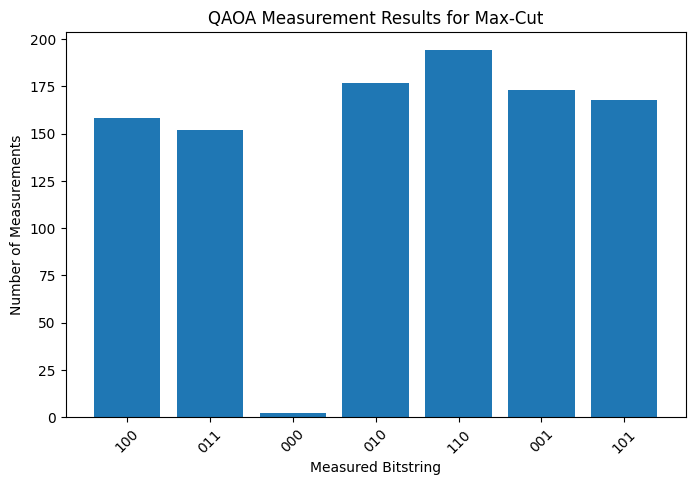

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(counts.keys(), counts.values())

plt.xlabel("Measured Bitstring")
plt.ylabel("Number of Measurements")
plt.title("QAOA Measurement Results for Max-Cut")

plt.xticks(rotation=45)
plt.show()

##Output Interpretation

The output of the program contains the measured bitstrings and their frequencies.

A bitstring appearing more frequently indicates that the optimized QAOA circuit assigns a higher probability to that particular solution.

The cut value is then calculated for the measured solutions.

The final result gives:

the measured solution/bitstring,
its corresponding partition,
and the number of edges cut.

The solution with the maximum calculated cut value is taken as the Max-Cut solution obtained using QAOA.